# Formative Assignment: Advanced Linear Algebra (PCA)

**Group / Peer Pair:** Team 22
**Members:**
1. Gatete Derrick
2. Abdul Kudus Zakaria Mukhtaru

**GitHub repo:** https://github.com/Abdull-Kudus/pca-rwanda-food-prices.git

This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .
1. Make sure to display outputs for each code cell when submitting.
2. Do not write all your code on one cell
3. Do not use any libraries aside from numpy (matplotlib is used only for plots)

### Dataset: Rwanda food prices (WFP / HDX)
**File:** `wfp_food_prices_rwa.csv`, downloaded unchanged from the World Food Programme's Rwanda - Food Prices dataset on the Humanitarian Data Exchange (HDX): [https://data.humdata.org/dataset/wfp-food-prices-for-rwanda](https://data.humdata.org/dataset/wfp-food-prices-for-rwanda)

**Why it matters:** food makes up a large share of household spending in Rwanda, so these prices show food security, inflation and regional inequality across the country.

The raw file has 16 columns and one row per (market, month, commodity): about 158,000 price records from 2000 to 2026. Several columns are text (non-numeric): date, admin1 (province), admin2 (district), market, category, commodity, unit, pricetype and others.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True, linewidth=120)

DATA_PATH = 'https://raw.githubusercontent.com/Abdull-Kudus/pca-rwanda-food-prices/main/wfp_food_prices_rwa.csv'

lines = np.genfromtxt(DATA_PATH, dtype=str, delimiter='\x01', comments=None, encoding='utf-8')

def split_csv_line(line):
    if '"' not in line: return line.split(',')
    fields, current, in_quotes = [], '', False
    for ch in line:
        if ch == '"': in_quotes = not in_quotes
        elif ch == ',' and not in_quotes: fields.append(current); current = ''
        else: current += ch
    fields.append(current)
    return fields

wfp_header = split_csv_line(lines[0].lstrip('\ufeff'))
wfp = np.array([split_csv_line(l) for l in lines[1:]])
print('Raw WFP data shape:', wfp.shape)
print('Columns:', wfp_header)
wfp[:3]

Raw WFP data shape: (157692, 16)
Columns: ['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']


array([['2000-01-15', 'Kigali City', 'Nyarugenge', 'Kigali', '1076', '-1.95', '30.06', 'cereals and tubers', 'Maize',
        '51', 'KG', 'actual', 'Wholesale', 'RWF', '206.11', '0.6'],
       ['2000-01-15', 'Kigali City', 'Nyarugenge', 'Kigali', '1076', '-1.95', '30.06', 'pulses and nuts', 'Beans',
        '50', 'KG', 'actual', 'Wholesale', 'RWF', '108.02', '0.32'],
       ['2000-02-15', 'Kigali City', 'Nyarugenge', 'Kigali', '1076', '-1.95', '30.06', 'cereals and tubers', 'Maize',
        '51', 'KG', 'actual', 'Wholesale', 'RWF', '152.66', '0.45']], dtype='<U38')

### Reshaping: one row per market per month
PCA needs each row to be one observation with the same features. We keep retail prices per KG for 9 staple foods from 2018 onwards, and reshape so that each row is a (market, month) and each food is a column.

When a food was not recorded in a market in a given month, its cell is left empty. These are the missing values we handle below. We keep market-months where at least 5 of the 9 prices were recorded.


In [7]:
col = {name: i for i, name in enumerate(wfp_header)}
foods = {
    'Beans (dry)': 'beans_rwf_kg', 'Maize': 'maize_rwf_kg', 'Maize flour': 'maize_flour_rwf_kg',
    'Potatoes (Irish)': 'irish_potato_rwf_kg', 'Cassava': 'cassava_rwf_kg',
    'Cassava flour': 'cassava_flour_rwf_kg', 'Sorghum': 'sorghum_rwf_kg',
    'Bananas': 'banana_rwf_kg', 'Rice (local)': 'rice_local_rwf_kg'
}
food_names = list(foods)

keep = (
    (wfp[:, col['pricetype']] == 'Retail') &
    (wfp[:, col['unit']] == 'KG') &
    np.isin(wfp[:, col['commodity']], food_names) &
    (wfp[:, col['date']] >= '2018')
)
sub = wfp[keep]

# one row per (date, market): find the unique pairs and where each record belongs
pair = np.char.add(np.char.add(sub[:, col['date']], '|'), sub[:, col['market']])
pairs, row_of = np.unique(pair, return_inverse=True)
food_of = np.array([food_names.index(c) for c in sub[:, col['commodity']]])

wide = np.full((len(pairs), len(food_names)), '', dtype=object)
wide[row_of, food_of] = sub[:, col['price']]

first = np.unique(row_of, return_index=True)[1]  # one record per pair, for the location columns
location = sub[first][:, [col['date'], col['admin1'], col['admin2'], col['market']]]
enough = (wide != '').sum(axis=1) >= 5

header = ['date', 'province', 'district', 'market'] + [foods[f] for f in food_names]
raw = np.column_stack([location, wide]).astype(str)[enough]

print('Reshaped data shape:', raw.shape)
print('Columns:', header)
raw[:5]

Reshaped data shape: (1875, 13)
Columns: ['date', 'province', 'district', 'market', 'beans_rwf_kg', 'maize_rwf_kg', 'maize_flour_rwf_kg', 'irish_potato_rwf_kg', 'cassava_rwf_kg', 'cassava_flour_rwf_kg', 'sorghum_rwf_kg', 'banana_rwf_kg', 'rice_local_rwf_kg']


array([['2018-01-15', 'Southern Province', 'Nyamagabe', 'Gasarenda', '300', '250', '450', '160', '200', '400', '300',
        '280', '750'],
       ['2018-01-15', 'Southern Province', 'Gisagara', 'Gatunda', '295', '', '500', '180', '160', '400', '575', '',
        '700'],
       ['2018-01-15', 'Northern Province', 'Gicumbi', 'Gicumbi', '350', '220', '500', '165', '300', '525', '400',
        '260', '750'],
       ['2018-01-15', 'Northern Province', 'Gicumbi', 'Gihembe (Camp)', '350', '260', '455', '180', '', '400', '400',
        '200', '690'],
       ['2018-01-15', 'Southern Province', 'Nyamagabe', 'Kabacuzi', '335', '290', '400', '150', '300', '500', '325',
        '280', '700']], dtype='<U17')

### Data inspection: missing values and non-numeric columns


In [8]:
text_cols = header[:4]   # date, province, district, market -> non-numeric
price_cols = header[4:]  # 9 commodity prices -> numeric

prices = np.where(raw[:, 4:] == '', 'nan', raw[:, 4:]).astype(float)
missing = np.isnan(prices).sum(axis=0)

print('Non-numeric columns:', list(text_cols))
print(f'Total missing values: {missing.sum()} ({missing.sum() / prices.size:.1%} of price cells)\n')
for name, m in zip(price_cols, missing):
    print(f'{name:<22} missing = {m:4d} ({m / len(prices):.1%})')

Non-numeric columns: ['date', 'province', 'district', 'market']
Total missing values: 1596 (9.5% of price cells)

beans_rwf_kg           missing =    6 (0.3%)
maize_rwf_kg           missing =   73 (3.9%)
maize_flour_rwf_kg     missing =   25 (1.3%)
irish_potato_rwf_kg    missing =   95 (5.1%)
cassava_rwf_kg         missing =  512 (27.3%)
cassava_flour_rwf_kg   missing =  146 (7.8%)
sorghum_rwf_kg         missing =  202 (10.8%)
banana_rwf_kg          missing =  247 (13.2%)
rice_local_rwf_kg      missing =  290 (15.5%)


In [9]:
for j, name in enumerate(text_cols):
    vals, counts = np.unique(raw[:, j], return_counts=True)
    print(f'{name:<9} -> {len(vals):3d} unique values, e.g. {vals[:4].tolist()}')

date      ->  97 unique values, e.g. ['2018-01-15', '2018-02-15', '2018-03-15', '2018-04-15']
province  ->   5 unique values, e.g. ['Eastern Province', 'Kigali City', 'Northern Province', 'Southern Province']
district  ->   7 unique values, e.g. ['Gatsibo', 'Gicumbi', 'Gisagara', 'Karongi']
market    ->  33 unique values, e.g. ['Bubare', 'Gasarenda', 'Gatore', 'Gatunda']


### Handling missing values: median imputation within each province
Prices differ between provinces, so we fill a missing price with the median of the same commodity in the same province. If a province has no values at all for a commodity, we fall back to the national median. We use the median instead of the mean because food prices have outliers (price spikes).

In [10]:
province = raw[:, 1]
imputed = prices.copy()

for j in range(imputed.shape[1]):
    col = imputed[:, j]
    national_median = np.nanmedian(col)

    for p in np.unique(province):
        in_p = province == p
        observed = col[in_p & ~np.isnan(col)]
        fill = np.median(observed) if observed.size else national_median
        col[in_p & np.isnan(col)] = fill

print('Missing values after imputation:', np.isnan(imputed).sum())
imputed[:5]

Missing values after imputation: 0


array([[300., 250., 450., 160., 200., 400., 300., 280., 750.],
       [295., 400., 500., 180., 160., 400., 575., 280., 700.],
       [350., 220., 500., 165., 300., 525., 400., 260., 750.],
       [350., 260., 455., 180., 150., 400., 400., 200., 690.],
       [335., 290., 400., 150., 300., 500., 325., 280., 700.]])

### Encoding non-numeric columns
* `date` -> numeric year (captures inflation over time).
* `province` (5 categories, no natural order) -> one-hot encoding with one category dropped (Eastern Province = reference). If we kept all 5 dummy columns they would sum to 1, and the covariance matrix would get an eigenvalue of exactly 0.
* `district` (7 values) and `market` (33 values) are location identifiers. One-hot encoding them would add about 40 sparse columns that would crowd out the price structure, so they are not used as PCA features. We keep them for labelling, and province already carries the regional information.


In [11]:
year = np.array([d[:4] for d in raw[:, 0]], dtype=float)
provinces = np.unique(province)
dummy_cats = provinces[1:]  # drop first category (Eastern Province)
province_onehot = (province[:, None] == dummy_cats[None, :]).astype(float)

X = np.column_stack([imputed, year, province_onehot])
feature_names = list(price_cols) + ['year'] + ['prov_' + c.replace(' Province', '').replace(' ', '_') for c in dummy_cats]

print('Final feature matrix shape:', X.shape)
print('Features:', feature_names)
X[:5]

Final feature matrix shape: (1875, 14)
Features: ['beans_rwf_kg', 'maize_rwf_kg', 'maize_flour_rwf_kg', 'irish_potato_rwf_kg', 'cassava_rwf_kg', 'cassava_flour_rwf_kg', 'sorghum_rwf_kg', 'banana_rwf_kg', 'rice_local_rwf_kg', 'year', 'prov_Kigali_City', 'prov_Northern', 'prov_Southern', 'prov_Western']


array([[ 300.,  250.,  450.,  160.,  200.,  400.,  300.,  280.,  750., 2018.,    0.,    0.,    1.,    0.],
       [ 295.,  400.,  500.,  180.,  160.,  400.,  575.,  280.,  700., 2018.,    0.,    0.,    1.,    0.],
       [ 350.,  220.,  500.,  165.,  300.,  525.,  400.,  260.,  750., 2018.,    0.,    1.,    0.,    0.],
       [ 350.,  260.,  455.,  180.,  150.,  400.,  400.,  200.,  690., 2018.,    0.,    1.,    0.,    0.],
       [ 335.,  290.,  400.,  150.,  300.,  500.,  325.,  280.,  700., 2018.,    0.,    0.,    1.,    0.]])

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

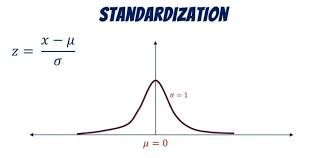


In [12]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mean = X.mean(axis=0)  # mu for each feature
std = np.sqrt(((X - mean) ** 2).sum(axis=0) / X.shape[0])  # sigma for each feature
standardized_data = (X - mean) / std  # z = (x - mu) / sigma
# (Do not use sklearn)

print('Means after standardization :', standardized_data.mean(axis=0).round(6))
print('Std devs after standardization:', standardized_data.std(axis=0).round(6))
standardized_data[:5]  # Display the first few rows of standardized data

Means after standardization : [ 0. -0.  0.  0.  0.  0. -0. -0.  0. -0. -0.  0.  0. -0.]
Std devs after standardization: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


array([[-1.247, -0.887, -1.22 , -1.494, -0.411, -0.593, -1.335, -0.01 , -0.624, -1.398, -0.069, -0.29 ,  1.315,
        -0.474],
       [-1.266,  0.08 , -0.974, -1.348, -0.775, -0.593,  0.103, -0.01 , -0.867, -1.398, -0.069, -0.29 ,  1.315,
        -0.474],
       [-1.065, -1.08 , -0.974, -1.458,  0.497,  0.028, -0.813, -0.176, -0.624, -1.398, -0.069,  3.454, -0.76 ,
        -0.474],
       [-1.065, -0.822, -1.195, -1.348, -0.865, -0.593, -0.813, -0.673, -0.915, -1.398, -0.069,  3.454, -0.76 ,
        -0.474],
       [-1.119, -0.629, -1.466, -1.567,  0.497, -0.096, -1.205, -0.01 , -0.867, -1.398, -0.069, -0.29 ,  1.315,
        -0.474]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [13]:
# Step 3: Calculate the Covariance Matrix
n = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)  # data is already centred

print('Shape:', cov_matrix.shape, '| symmetric:', np.allclose(cov_matrix, cov_matrix.T))
cov_matrix

Shape: (14, 14) | symmetric: True


array([[ 1.001,  0.768,  0.778,  0.717,  0.469,  0.588,  0.688,  0.492,  0.617,  0.665,  0.011, -0.169,  0.006,
         0.128],
       [ 0.768,  1.001,  0.803,  0.581,  0.41 ,  0.462,  0.75 ,  0.514,  0.6  ,  0.687,  0.001, -0.198,  0.141,
         0.073],
       [ 0.778,  0.803,  1.001,  0.724,  0.528,  0.682,  0.725,  0.54 ,  0.768,  0.795,  0.046, -0.222, -0.021,
        -0.002],
       [ 0.717,  0.581,  0.724,  1.001,  0.531,  0.7  ,  0.697,  0.575,  0.655,  0.816,  0.101, -0.272,  0.038,
        -0.003],
       [ 0.469,  0.41 ,  0.528,  0.531,  1.001,  0.546,  0.472,  0.44 ,  0.533,  0.559,  0.082, -0.212, -0.153,
         0.006],
       [ 0.588,  0.462,  0.682,  0.7  ,  0.546,  1.001,  0.525,  0.518,  0.665,  0.686,  0.029, -0.157, -0.101,
        -0.038],
       [ 0.688,  0.75 ,  0.725,  0.697,  0.472,  0.525,  1.001,  0.589,  0.592,  0.782,  0.005, -0.247,  0.165,
         0.089],
       [ 0.492,  0.514,  0.54 ,  0.575,  0.44 ,  0.518,  0.589,  1.001,  0.473,  0.63 ,  0.011, -

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

We compute the covariance matrix to understand the relationships between different features (whether they vary together). Secondly, it captures the dataset's variance and covariance structure, which is essential for identifying the principal directions (eigenvectors) of maximum variance in PCA.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [14]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# sanity check: C v = lambda v for every pair
print('C v = lambda v holds:', np.allclose(cov_matrix @ eigenvectors, eigenvectors * eigenvalues))
eigenvalues, eigenvectors

C v = lambda v holds: True


(array([0.117, 0.121, 0.176, 0.247, 0.293, 0.345, 0.381, 0.502, 0.639, 0.841, 1.016, 1.118, 1.455, 6.756]),
 array([[-0.446,  0.005, -0.308, -0.319, -0.091, -0.49 ,  0.352,  0.066, -0.188,  0.258,  0.115, -0.076, -0.062,
          0.321],
        [ 0.295,  0.533,  0.291,  0.227, -0.158, -0.127, -0.185,  0.287, -0.233,  0.375,  0.118, -0.147,  0.079,
          0.313],
        [ 0.13 , -0.789,  0.255,  0.13 , -0.144, -0.089, -0.198,  0.004, -0.266,  0.096,  0.077,  0.047, -0.033,
          0.348],
        [ 0.526,  0.056,  0.173, -0.431, -0.056,  0.172,  0.509, -0.292,  0.041, -0.058, -0.07 ,  0.079,  0.009,
          0.333],
        [ 0.028, -0.037,  0.091, -0.04 ,  0.225, -0.066,  0.124,  0.758,  0.22 , -0.397, -0.115,  0.175, -0.17 ,
          0.254],
        [ 0.017,  0.143, -0.048,  0.594,  0.23 , -0.365,  0.134, -0.418,  0.073, -0.29 ,  0.061,  0.226, -0.11 ,
          0.298],
        [ 0.078, -0.1  , -0.604,  0.327,  0.079,  0.527,  0.151,  0.129,  0.061,  0.215,  0.039, -0.147,  

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [15]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly (columns = PCs)

print('Sorted eigenvalues:', sorted_eigenvalues)
sorted_eigenvectors

Sorted eigenvalues: [6.756 1.455 1.118 1.016 0.841 0.639 0.502 0.381 0.345 0.293 0.247 0.176 0.121 0.117]


array([[ 0.321, -0.062, -0.076,  0.115,  0.258, -0.188,  0.066,  0.352, -0.49 , -0.091, -0.319, -0.308,  0.005,
        -0.446],
       [ 0.313,  0.079, -0.147,  0.118,  0.375, -0.233,  0.287, -0.185, -0.127, -0.158,  0.227,  0.291,  0.533,
         0.295],
       [ 0.348, -0.033,  0.047,  0.077,  0.096, -0.266,  0.004, -0.198, -0.089, -0.144,  0.13 ,  0.255, -0.789,
         0.13 ],
       [ 0.333,  0.009,  0.079, -0.07 , -0.058,  0.041, -0.292,  0.509,  0.172, -0.056, -0.431,  0.173,  0.056,
         0.526],
       [ 0.254, -0.17 ,  0.175, -0.115, -0.397,  0.22 ,  0.758,  0.124, -0.066,  0.225, -0.04 ,  0.091, -0.037,
         0.028],
       [ 0.298, -0.11 ,  0.226,  0.061, -0.29 ,  0.073, -0.418,  0.134, -0.365,  0.23 ,  0.594, -0.048,  0.143,
         0.017],
       [ 0.325,  0.101, -0.147,  0.039,  0.215,  0.061,  0.129,  0.151,  0.527,  0.079,  0.327, -0.604, -0.1  ,
         0.078],
       [ 0.269,  0.169, -0.035,  0.015,  0.013,  0.746, -0.087, -0.345, -0.173, -0.398, -0.118, -

### Task 2: Explained variance and dynamic selection of components
Each eigenvalue is the variance captured by its principal component, so
$$ \text{explained variance ratio}_i = \frac{\lambda_i}{\sum_j \lambda_j} $$

We dynamically keep the smallest number of components whose cumulative explained variance reaches a chosen threshold. We also print the Kaiser rule (eigenvalue > 1) for comparison.


In [16]:
explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f'{"PC":<5}{"eigenvalue":>11}{"explained":>11}{"cumulative":>12}')
for i, (ev, r, c) in enumerate(zip(sorted_eigenvalues, explained_variance_ratio, cumulative_variance), 1):
    print(f'PC{i:<3}{ev:>11.3f}{r:>11.2%}{c:>12.2%}')

PC    eigenvalue  explained  cumulative
PC1        6.756     48.23%      48.23%
PC2        1.455     10.39%      58.62%
PC3        1.118      7.98%      66.60%
PC4        1.016      7.25%      73.85%
PC5        0.841      6.01%      79.86%
PC6        0.639      4.56%      84.42%
PC7        0.502      3.58%      88.00%
PC8        0.381      2.72%      90.72%
PC9        0.345      2.46%      93.18%
PC10       0.293      2.09%      95.28%
PC11       0.247      1.77%      97.04%
PC12       0.176      1.26%      98.30%
PC13       0.121      0.87%      99.17%
PC14       0.117      0.83%     100.00%


In [17]:
def select_num_components(eigvals_sorted, threshold=0.85):
    """Smallest k such that the first k components explain >= threshold of total variance."""
    cumulative = np.cumsum(eigvals_sorted) / eigvals_sorted.sum()
    return int(np.searchsorted(cumulative, threshold) + 1)

VARIANCE_THRESHOLD = 0.85  # <- team decision, justify it in the answers below

for thr in [0.70, 0.80, 0.85, 0.90, 0.95]:
    print(f'threshold {thr:.0%} -> {select_num_components(sorted_eigenvalues, thr)} components')

print('Kaiser rule (eigenvalue > 1) ->', int((sorted_eigenvalues > 1).sum()), 'components')

threshold 70% -> 4 components
threshold 80% -> 6 components
threshold 85% -> 7 components
threshold 90% -> 8 components
threshold 95% -> 10 components
Kaiser rule (eigenvalue > 1) -> 4 components


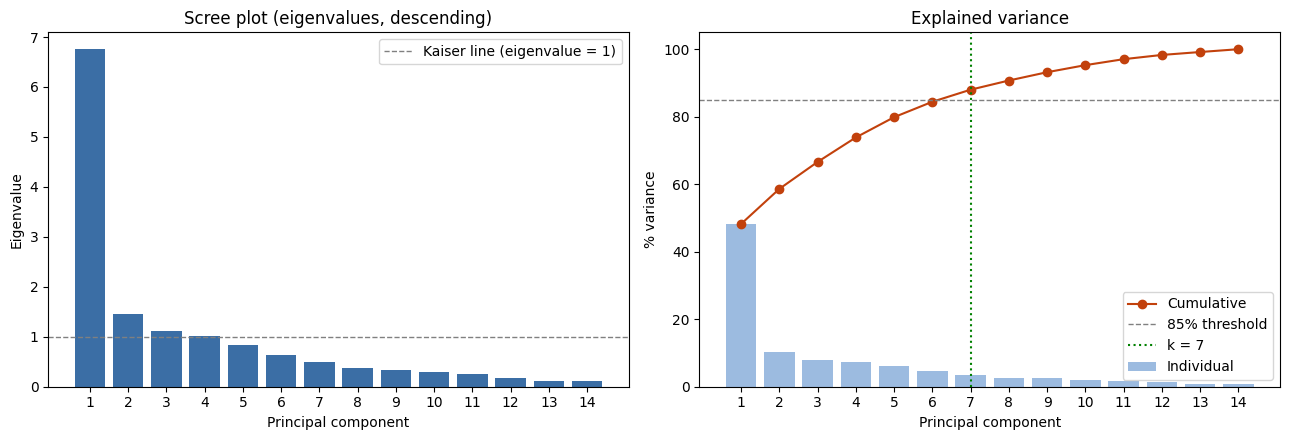

In [18]:
k_sel = select_num_components(sorted_eigenvalues, VARIANCE_THRESHOLD)
pcs = np.arange(1, len(sorted_eigenvalues) + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(pcs, sorted_eigenvalues, color='#3b6ea5')
ax[0].axhline(1, color='gray', ls='--', lw=1, label='Kaiser line (eigenvalue = 1)')
ax[0].set(title='Scree plot (eigenvalues, descending)', xlabel='Principal component', ylabel='Eigenvalue', xticks=pcs)
ax[0].legend()

ax[1].bar(pcs, explained_variance_ratio * 100, color='#9cbbe0', label='Individual')
ax[1].plot(pcs, cumulative_variance * 100, 'o-', color='#c2410c', label='Cumulative')
ax[1].axhline(VARIANCE_THRESHOLD * 100, color='gray', ls='--', lw=1, label=f'{VARIANCE_THRESHOLD:.0%} threshold')
ax[1].axvline(k_sel, color='green', ls=':', lw=1.5, label=f'k = {k_sel}')
ax[1].set(title='Explained variance', xlabel='Principal component', ylabel='% variance', xticks=pcs)
ax[1].legend()

plt.tight_layout(); plt.show()

### What do the top components mean? (loadings)
The loadings are the eigenvector entries. They show how much each original feature contributes to each principal component. We use them to interpret the components (for example, "general food price level" vs. "regional differences").


feature                    PC1     PC2     PC3     PC4
beans_rwf_kg              0.32   -0.06   -0.08    0.11
maize_rwf_kg              0.31    0.08   -0.15    0.12
maize_flour_rwf_kg        0.35   -0.03    0.05    0.08
irish_potato_rwf_kg       0.33    0.01    0.08   -0.07
cassava_rwf_kg            0.25   -0.17    0.17   -0.12
cassava_flour_rwf_kg      0.30   -0.11    0.23    0.06
sorghum_rwf_kg            0.32    0.10   -0.15    0.04
banana_rwf_kg             0.27    0.17   -0.04    0.01
rice_local_rwf_kg         0.31   -0.12    0.10    0.01
year                      0.35    0.04    0.02    0.01
prov_Kigali_City          0.02   -0.09    0.44   -0.77
prov_Northern            -0.12   -0.18    0.50    0.57
prov_Southern             0.02    0.76   -0.14   -0.07
prov_Western              0.02   -0.52   -0.62   -0.14


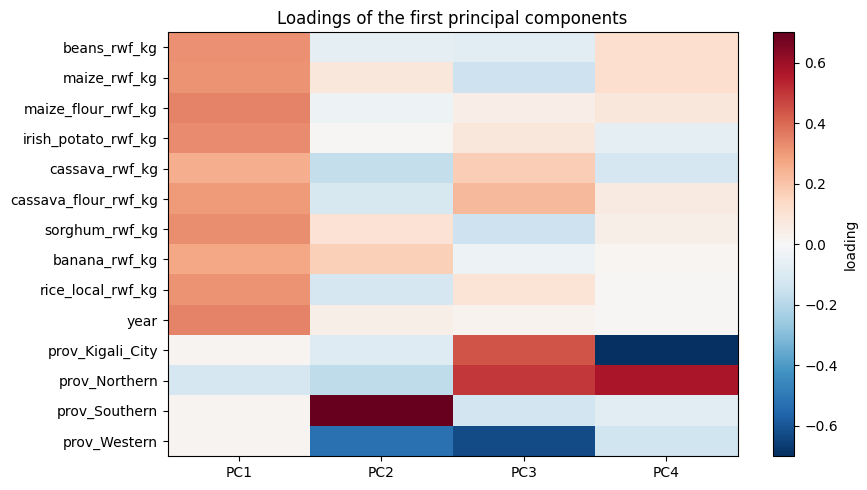

In [19]:
top = 4
print(f'{"feature":<22}' + ''.join(f'{"PC" + str(i + 1):>8}' for i in range(top)))
for f, row in zip(feature_names, sorted_eigenvectors[:, :top]):
    print(f'{f:<22}' + ''.join(f'{v:>8.2f}' for v in row))

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(sorted_eigenvectors[:, :top], cmap='RdBu_r', vmin=-0.7, vmax=0.7, aspect='auto')
ax.set_yticks(range(len(feature_names)), feature_names)
ax.set_xticks(range(top), [f'PC{i + 1}' for i in range(top)])
ax.set_title('Loadings of the first principal components')
plt.colorbar(im, label='loading'); plt.tight_layout(); plt.show()

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [21]:
# Step 6: Project Data onto Principal Components
num_components = k_sel  # Decided dynamically from explained variance (Task 2)
W = sorted_eigenvectors[:, :num_components]  # projection matrix (features x k)

reduced_data = standardized_data @ W  # Project data onto the principal components

print(f'Keeping {num_components} of {X.shape[1]} components -> {cumulative_variance[num_components - 1]:.2%} of variance retained')
reduced_data[:5]


Keeping 7 of 14 components -> 88.00% of variance retained


array([[-2.953,  1.359, -0.108, -0.437, -0.586,  0.498,  0.194],
       [-2.224,  1.665, -0.524, -0.219,  0.273,  0.281,  0.376],
       [-2.802, -1.126,  2.291,  1.822,  0.419,  1.402,  0.751],
       [-3.519, -0.848,  1.863,  1.937,  1.241,  0.759,  0.108],
       [-2.596,  1.211,  0.055, -0.476, -0.919,  0.777,  0.833]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [22]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
print('Variance of each PC score :', reduced_data.var(axis=0, ddof=1).round(3))
print('Matching eigenvalues :', sorted_eigenvalues[:num_components].round(3))
reduced_data[:5]  # Display the first few rows of reduced data


Reduced Data Shape: (1875, 7)
Variance of each PC score : [6.756 1.455 1.118 1.016 0.841 0.639 0.502]
Matching eigenvalues : [6.756 1.455 1.118 1.016 0.841 0.639 0.502]


array([[-2.953,  1.359, -0.108, -0.437, -0.586,  0.498,  0.194],
       [-2.224,  1.665, -0.524, -0.219,  0.273,  0.281,  0.376],
       [-2.802, -1.126,  2.291,  1.822,  0.419,  1.402,  0.751],
       [-3.519, -0.848,  1.863,  1.937,  1.241,  0.759,  0.108],
       [-2.596,  1.211,  0.055, -0.476, -0.919,  0.777,  0.833]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

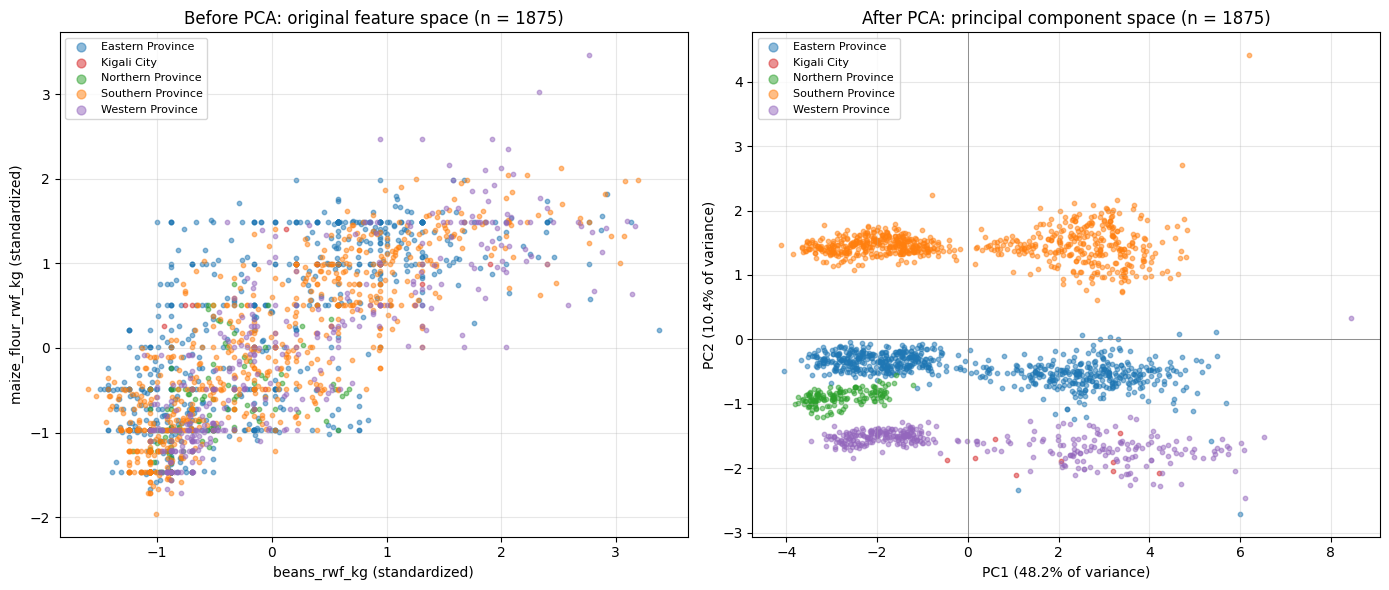

Points before: 1875 | points after: 1875
Var(PC1) = 6.756 > Var(PC2) = 1.455
Mean of PC scores (centred): [-0. -0.]


In [24]:
# Step 8: Visualize Before and After PCA
colors = {'Eastern Province': '#1f77b4', 'Kigali City': '#d62728',
          'Northern Province': '#2ca02c', 'Southern Province': '#ff7f0e', 'Western Province': '#9467bd'}

fi, fj = feature_names.index('beans_rwf_kg'), feature_names.index('maize_flour_rwf_kg')

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot original data (two original features)
for p, c in colors.items():
    m = province == p
    ax[0].scatter(standardized_data[m, fi], standardized_data[m, fj], s=10, alpha=0.5, c=c, label=p)
ax[0].set(title=f'Before PCA: original feature space (n = {len(X)})',
          xlabel='beans_rwf_kg (standardized)', ylabel='maize_flour_rwf_kg (standardized)')

# Plot reduced data after PCA
for p, c in colors.items():
    m = province == p
    ax[1].scatter(reduced_data[m, 0], reduced_data[m, 1], s=10, alpha=0.5, c=c, label=p)
ax[1].axhline(0, color='gray', lw=0.6); ax[1].axvline(0, color='gray', lw=0.6)
ax[1].set(title=f'After PCA: principal component space (n = {len(reduced_data)})',
          xlabel=f'PC1 ({explained_variance_ratio[0]:.1%} of variance)',
          ylabel=f'PC2 ({explained_variance_ratio[1]:.1%} of variance)')

for a in ax:
    a.legend(markerscale=2, fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Points before:', len(X), '| points after:', len(reduced_data))
print(f'Var(PC1) = {reduced_data[:, 0].var(ddof=1):.3f} > Var(PC2) = {reduced_data[:, 1].var(ddof=1):.3f}')
print('Mean of PC scores (centred):', reduced_data[:, :2].mean(axis=0).round(6))

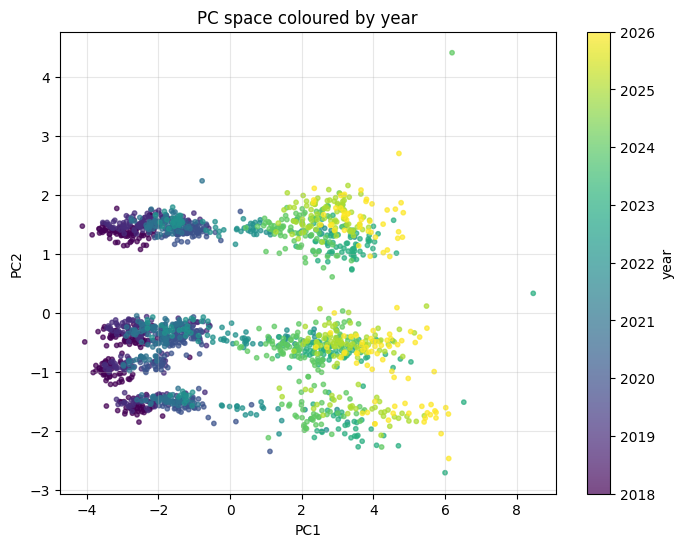

In [25]:
# Same PC space coloured by year, to show what PC1 is picking up
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(reduced_data[:, 0], reduced_data[:, 1], c=year, cmap='viridis', s=10, alpha=0.7)
plt.colorbar(sc, label='year')
ax.set(title='PC space coloured by year', xlabel='PC1', ylabel='PC2'); ax.grid(alpha=0.3)
plt.show()

### 1. Interpret the Visual you just created of the before and after PCA
**Answer:** The "Before PCA" plot shows overlapping clusters based on just two raw features, making trends hard to distinguish. The "After PCA" plot (PC1 vs PC2) better separates the data (e.g., distinct clusters for Southern and Western Provinces) along axes of maximum variance, capturing more dataset structure in 2D.

### 2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
**Answer:** We selected 7 principal components because they explain 85% of the total variance, meeting our threshold. The tradeoff is reducing dimensionality from 14 to 7 to simplify the model and improve computational efficiency, at the acceptable cost of losing 15% of the original dataset variance.

### 3. Clearly mention based on your use case/ dataset ("economic activity", "population pressure"), What information is lost when reducing dimensions?
**Answer:** For this Rwanda food prices dataset, reducing dimensions means losing minor, highly localized price fluctuations or specific unique commodity price spikes. The main regional trends and overarching inflation patterns are preserved, but idiosyncratic market anomalies might be discarded as noise.


### Task 3: Optimising PCA for performance and large datasets

Optimisations used / tested:
* **Vectorised covariance** (`Z^T Z / (n-1)`, one matrix multiply) instead of Python loops over feature pairs.
* **`eigh` instead of `eig`**: it uses a faster algorithm made for symmetric matrices and always returns real results.
* **Chunked (streaming) covariance** for data that is too big for memory: we add up `sum(x)` and `X^T X` one block at a time, so memory stays at $O(d^2)$ however many rows there are.
* **float32**, which halves memory use for very large inputs.

In [26]:
import time

def timeit(fn, repeat=3):
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); best = min(best, time.perf_counter() - t0)
    return best

def cov_loops(Z):
    n_, d = Z.shape
    C = np.zeros((d, d))
    for i in range(d):
        for j in range(d):
            s = 0.0
            for r in range(n_):
                s += Z[r, i] * Z[r, j]
            C[i, j] = s / (n_ - 1)
    return C

def cov_vectorised(Z):
    return Z.T @ Z / (Z.shape[0] - 1)

sub = standardized_data[:300]
t_loop, t_vec = timeit(lambda: cov_loops(sub), 1), timeit(lambda: cov_vectorised(sub))
print(f'Covariance on 300 rows -> loops: {t_loop * 1000:.1f} ms | vectorised: {t_vec * 1000:.3f} ms | speed-up ~ {t_loop / t_vec:,.0f}x')
print('Same result:', np.allclose(cov_loops(sub), cov_vectorised(sub)))

t_eig, t_eigh = timeit(lambda: np.linalg.eig(cov_matrix), 50), timeit(lambda: np.linalg.eigh(cov_matrix), 50)
print(f'Eigendecomposition -> eig: {t_eig * 1e6:.0f} us | eigh: {t_eigh * 1e6:.0f} us')

Covariance on 300 rows -> loops: 26.3 ms | vectorised: 0.016 ms | speed-up ~ 1,681x
Same result: True
Eigendecomposition -> eig: 70 us | eigh: 36 us


In [27]:
def pca_fit_chunked(X, chunk_size=100_000):
    """PCA with one streaming pass over the rows: memory O(d^2), so it also works on data larger than RAM (X can be a np.memmap).
       Returns mean, std, sorted eigenvalues, sorted eigenvectors."""
    n_, d = X.shape
    s, ss, xtx = np.zeros(d), np.zeros(d), np.zeros((d, d))

    for start in range(0, n_, chunk_size):
        B = X[start:start + chunk_size].astype(np.float64)
        s += B.sum(0); ss += (B ** 2).sum(0); xtx += B.T @ B

    mean_ = s / n_
    std_ = np.sqrt(ss / n_ - mean_ ** 2)

    cov_raw = (xtx - n_ * np.outer(mean_, mean_)) / (n_ - 1)
    cov_std = cov_raw / np.outer(std_, std_)  # = covariance of the standardized data

    vals, vecs = np.linalg.eigh(cov_std)
    order = np.argsort(vals)[::-1]

    return mean_, std_, vals[order], vecs[:, order]

def pca_transform_chunked(X, mean_, std_, W_, chunk_size=100_000):
    out = np.empty((X.shape[0], W_.shape[1]), dtype=np.float32)
    for start in range(0, X.shape[0], chunk_size):
        out[start:start + chunk_size] = ((X[start:start + chunk_size] - mean_) / std_) @ W_
    return out

# check: the chunked version gives the same eigenvalues as the step-by-step version above
_, _, vals_c, _ = pca_fit_chunked(X, chunk_size=250)
print('Chunked eigenvalues match step-by-step PCA:', np.allclose(vals_c, sorted_eigenvalues))

Chunked eigenvalues match step-by-step PCA: True


N =    10,000 rows | in-memory:  0.006 s | chunked/streaming:  0.003 s | data size =    0.6 MB
N =   100,000 rows | in-memory:  0.056 s | chunked/streaming:  0.026 s | data size =    5.6 MB
N =   500,000 rows | in-memory:  0.146 s | chunked/streaming:  0.134 s | data size =   28.0 MB
N = 1,000,000 rows | in-memory:  0.296 s | chunked/streaming:  0.274 s | data size =   56.0 MB
N = 2,000,000 rows | in-memory:  0.594 s | chunked/streaming:  0.935 s | data size =  112.0 MB


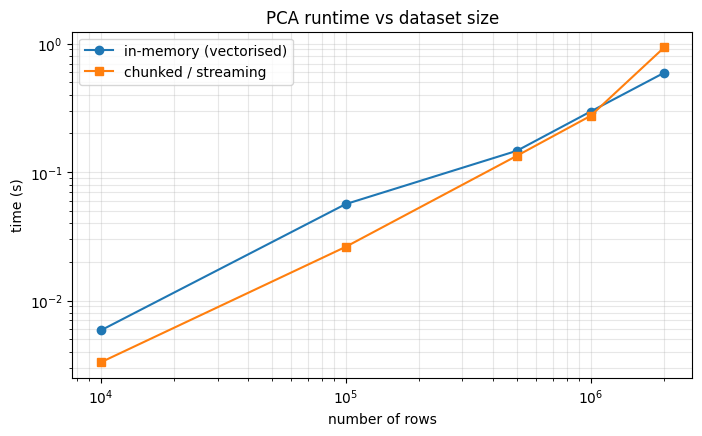

In [28]:
# Benchmark on large synthetic versions of the dataset (rows resampled + 2% noise)
rng = np.random.default_rng(42)
sizes = [10_000, 100_000, 500_000, 1_000_000, 2_000_000]
t_full, t_chunk = [], []

for N in sizes:
    big = (X[rng.integers(0, len(X), N)] * (1 + 0.02 * rng.standard_normal((N, X.shape[1])))).astype(np.float32)

    def full_pipeline():
        Zb = (big - big.mean(0)) / big.std(0)
        vals, vecs = np.linalg.eigh(Zb.T @ Zb / (N - 1))
        return Zb @ vecs[:, ::-1][:, :num_components]

    def chunked_pipeline():
        m_, s_, vals, vecs = pca_fit_chunked(big)
        return pca_transform_chunked(big, m_, s_, vecs[:, :num_components])

    t_full.append(timeit(full_pipeline, 1)); t_chunk.append(timeit(chunked_pipeline, 1))
    print(f'N = {N:>9,} rows | in-memory: {t_full[-1]:6.3f} s | chunked/streaming: {t_chunk[-1]:6.3f} s | data size = {big.nbytes / 1e6:6.1f} MB')
    del big

plt.figure(figsize=(8, 4.5))
plt.plot(sizes, t_full, 'o-', label='in-memory (vectorised)')
plt.plot(sizes, t_chunk, 's-', label='chunked / streaming')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('number of rows'); plt.ylabel('time (s)'); plt.title('PCA runtime vs dataset size')
plt.legend(); plt.grid(alpha=0.3, which='both'); plt.show()

**Benchmark takeaway:** the vectorised covariance is more than 1000x faster than Python loops and gives the same result. Runtime grows roughly linearly with the number of rows, because the expensive part is building the $d \times d$ covariance matrix (cost $O(n d^2)$). The eigendecomposition only works on a $14 \times 14$ matrix, so it is almost free. The chunked version is a little slower, since it goes over the data twice, but it never builds a full standardized copy of the data. Its extra memory is therefore constant (one chunk plus a $14 \times 14$ matrix), so it can run on files bigger than RAM (for example with `np.memmap`). The trade-off is speed for memory.